<a href="https://colab.research.google.com/github/NicoNestasio/Antena-Vivaldi/blob/acostada/Vivaldi_5_15GHz_Segundo_Modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***5.15Ghz***

   Unnamed: 0  Positions  Amplitudes
0           0      360.0   10.794695
1           1      360.0   10.817695
2           2      360.0   10.886695
3           3      360.0   10.787695
4           4      359.8   10.798695
Index(['Unnamed: 0', 'Positions', 'Amplitudes'], dtype='object')


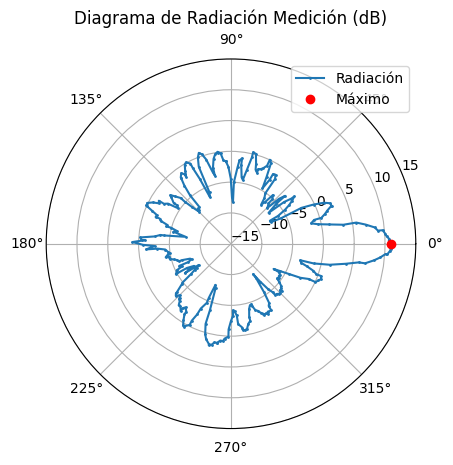

Máximo: 10.971695174459462


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Ruta del archivo Excel
ruta_csv = '/content/Pol. Principal - Diagrama de radiación-corrected.csv'

# Importar datos desde Excel a un DataFrame de pandas
datos = pd.read_csv(ruta_csv)
datos['Positions'] = datos['Positions'].str.replace('deg', '').astype(float)
datos['Amplitudes'] = datos['Amplitudes'].str.replace('dB', '').astype(float)

# Ver los primeros registros para asegurarte de que los datos se importaron correctamente
print(datos.head())
print(datos.columns)

# Acceder a los datos de las columnas
angulos = np.deg2rad(datos['Positions'])
amplitudes = datos['Amplitudes']


# Encontrar el punto máximo
maximo_idx = np.argmax(amplitudes)
angulo_max = angulos[maximo_idx]
amplitud_max = amplitudes[maximo_idx]

# Crear el gráfico
plt.figure()
plt.polar(angulos, amplitudes, marker='o', markersize=1, label='Radiación')
plt.polar(0, amplitud_max, 'ro', label='Máximo')
plt.title('Diagrama de Radiación Medición (dB)')
plt.legend()
plt.ylim(-15, 15)
plt.yticks(np.arange(-15, 16, 5))
plt.show()
print('Máximo:',amplitud_max)


   Theta [deg]  dB(RealizedGainTotal) [] - Freq='5.15GHz' Phi='90deg'  \
0            0                                          -2.247173       
1            2                                          -5.546434       
2            4                                         -11.088496       
3            6                                         -17.220563       
4            8                                          -9.412048       

   dB(RealizedGainTotal) [] - Freq='5.25GHz' Phi='90deg'  \
0                                          -0.955823       
1                                          -3.369578       
2                                          -7.046015       
3                                         -13.368916       
4                                         -15.390797       

   dB(RealizedGainTotal) [] - Freq='5.35GHz' Phi='90deg'  \
0                                           0.179206       
1                                          -1.607840       
2                   

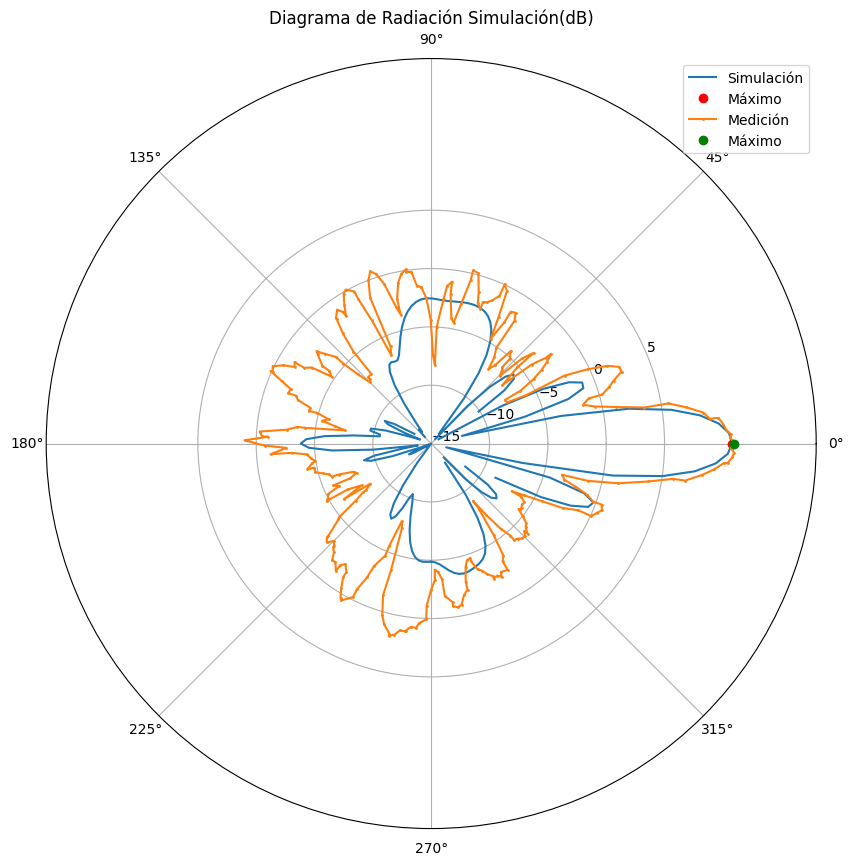

Máximo Simulado: 10.7863372966589
Máximo Medido: 10.971695174459462
Diferencia: -0.18535787780056268


In [21]:
# Gràfico (Simulación)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Ruta del archivo Excel
ruta_csv4 = '/content/Gain Plot 5 GHz_ComparacionMedicion.csv'

# Importar datos desde Excel a un DataFrame de pandas
datos4 = pd.read_csv(ruta_csv4)
# Ver los primeros registros para asegurarte de que los datos se importaron correctamente
print(datos4.head())
print(datos4.columns)

# Acceder a los datos de las columnas
angulos4 = np.deg2rad(datos4['Theta [deg]']-90)
amplitudes4 = datos4["dB(RealizedGainTotal)_1 [] - Freq='5.15GHz' Theta='90deg'"]


# Encontrar el punto máximo
maximo_idx4 = np.argmax(amplitudes4)
angulo_max4 = angulos4[maximo_idx4]
amplitud_max4 = amplitudes4[maximo_idx4]
dif_max=amplitud_max4-amplitud_max

# Crear el gráfico
plt.figure(figsize=(10, 10))
plt.polar(angulos4, amplitudes4, marker='o', markersize=0, label='Simulación')
plt.polar(angulo_max4, amplitud_max4, 'ro', label='Máximo')
plt.polar(angulos, amplitudes, marker='o', markersize=1, label='Medición')
plt.polar(0, amplitud_max, 'go', label='Máximo')
plt.title('Diagrama de Radiación Simulación(dB)')
plt.legend()
plt.ylim(-15, 18)  # Por ejemplo, establece el mínimo en 0 y el máximo en 20 dB
plt.yticks(np.arange(-15  , 10, 5))
plt.show()
plt.show()
print('Máximo Simulado:',amplitud_max4 )
print('Máximo Medido:',amplitud_max )
print('Diferencia:', dif_max)